# Expected goals (xG) from NHL play-by-play

Predict P(goal) for every **unblocked** shot (Fenwick basis — blocked shots have no reliable
location, xG = 0), following three notebooks from fastai's *Practical Deep Learning for Coders*
(cloned to `../course22`):

1. **Feature engineering / normalization** — [05-linear-model-and-neural-net-from-scratch](https://github.com/fastai/course22/blob/master/05-linear-model-and-neural-net-from-scratch.ipynb)
2. **Decision tree → random forest → feature importance** — [07-how-random-forests-really-work](https://github.com/fastai/course22/blob/master/07-how-random-forests-really-work.ipynb)
3. **Neural net trained by gradient descent, from scratch** — [04-how-does-a-neural-net-really-work](https://github.com/fastai/course22/blob/master/04-how-does-a-neural-net-really-work.ipynb)

Helpers live in the `xg` package (`xg/data.py`, `xg/features.py`, `xg/trees.py`, `xg/nn.py`).
Per plan, we start with **all** shot-row features — including identifiers like `event_id` and
`shooter_id` — and let feature importance tell us what to prune later. Public xG models run
~77–80% accurate (AUC ≈ 0.75–0.80); that's the bar.

In [1]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from xg import data, features, trees, nn

pd.set_option('display.width', 140)
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False)

## 0. Load shots

Every game already cached in postgres (`nhl.game_pbp_raw`) — instant, reproducible, zero API
calls. One row per unblocked shot with location, shot type, strength state, score state,
preceding event, rebound/rush flags.

In [2]:
shots = data.load_cached_shots(season="20232024")
shots.shape, shots.game_id.nunique(), shots.is_goal.mean()

((12050, 40), 134, np.float64(0.06937759336099585))

In [3]:
shots.head(3).T

,0,1,2
game_id,2023020001,2023020001,2023020001
season,20232024,20232024,20232024
game_date,2023-10-10,2023-10-10,2023-10-10
venue,Amalie Arena,Amalie Arena,Amalie Arena
venue_location,Tampa,Tampa,Tampa
home_team,TBL,TBL,TBL
away_team,NSH,NSH,NSH
shooting_team,TBL,TBL,TBL
opponent_team,NSH,NSH,NSH
is_home_shot,True,True,True


~7% of unblocked shots are goals. That base rate matters: *accuracy* is useless here (predicting
"never a goal" is 93% accurate), so we evaluate with **log loss**, **AUC**, and calibration.

## 1. Feature engineering & normalization (nb05)

`features.model_frame` keeps everything except the label leak (`event_type` — "goal" *is* the
label), exact string duplicates (`shooter_name`, `time_in_period`, …) and the constant `season`;
`game_date` becomes a day-of-season ordinal and categoricals get pandas `Categorical` dtype.

In [4]:
df = features.model_frame(shots)
df.isna().sum()[lambda s: s > 0]

shot_type           1
goalie_id          88
prev_event_zone    67
dtype: int64

Missing values: shots with no coordinates (rare) and first-event-of-period shots with no
previous event. nb05 fills with column modes — same here, but computed on the **train split only**
(one improvement on the course notebook: no peeking at validation data).

First, nb05's other trick: log-transform long-tailed columns. `seconds_since_prev` is the
obvious one:

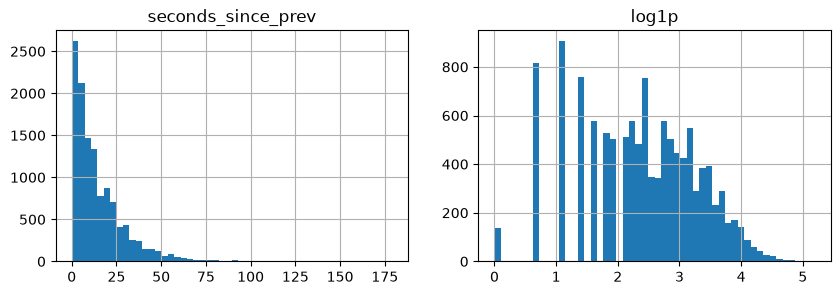

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
df.seconds_since_prev.hist(bins=50, ax=axs[0]); axs[0].set_title('seconds_since_prev')
np.log1p(df.seconds_since_prev).hist(bins=50, ax=axs[1]); axs[1].set_title('log1p');

In [6]:
df = features.add_log_cols(df)

trn, val = data.split_by_game(df)          # split on whole games, so rebound chains don't straddle
trn, modes = features.fill_missing(trn)
val, _ = features.fill_missing(val, modes)  # train-set modes
len(trn), len(val), int(trn.is_goal.sum()), int(val.is_goal.sum())

(8946, 3104, 613, 223)

In [7]:
trn.describe(include=np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
game_id,8946.0,2.023021e+09,388.11,2.023020e+09,2.023020e+09,2.023021e+09,2.023021e+09,2.023021e+09
event_id,8946.0,2.408130e+03,17268.55,8.000000e+00,2.660000e+02,5.870000e+02,8.377500e+02,1.652640e+05
game_seconds,8946.0,1.828320e+03,1052.34,3.000000e+00,9.220000e+02,1.821000e+03,2.729000e+03,4.800000e+03
is_goal,8946.0,7.000000e-02,0.25,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
x_coord,8946.0,-1.000000e+00,64.62,-9.800000e+01,-6.500000e+01,-2.050000e+01,6.500000e+01,9.900000e+01
y_coord,8946.0,-4.300000e-01,20.13,-4.200000e+01,-1.600000e+01,0.000000e+00,1.400000e+01,4.200000e+01
shot_distance,8946.0,3.375000e+01,19.60,1.410000e+00,1.664000e+01,3.239000e+01,4.807000e+01,9.799000e+01
shot_angle,8946.0,3.442000e+01,22.96,0.000000e+00,1.747000e+01,3.192000e+01,4.720000e+01,1.800000e+02
shooter_skaters,8946.0,4.960000e+00,0.36,1.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00
opponent_skaters,8946.0,4.810000e+00,0.49,0.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00


## 2. Binary splits → decision tree → random forest (nb07)

Trees split on thresholds, so categoricals become integer codes (`tree_frame`) — no dummies
needed, even for ~700 distinct shooters.

nb07 starts with the "1R" idea: score every possible single split of every column by
weighted within-side std of the target (lower = purer sides). Which single question tells you
most about whether a shot becomes a goal?

In [8]:
trn_t, val_t = features.tree_frame(trn), features.tree_frame(val)
trn_xs, trn_y = features.xs_y(trn_t)
val_xs, val_y = features.xs_y(val_t)

demo_cols = ['shot_distance', 'shot_angle', 'x_coord', 'is_rebound', 'is_empty_net',
             'shot_type', 'strength_state', 'seconds_since_prev']
{k: (round(float(t), 2), round(float(s), 4)) for k, (t, s) in trees.all_best_splits(trn_t, demo_cols, 'is_goal').items()}

{'shot_distance': (39.4, 0.2397),
 'is_empty_net': (0.0, 0.2483),
 'x_coord': (67.0, 0.2503),
 'strength_state': (9.0, 0.2504),
 'shot_angle': (12.53, 0.2507),
 'is_rebound': (0.0, 0.2512),
 'seconds_since_prev': (8.0, 0.2519),
 'shot_type': (8.0, 0.2525)}

`shot_distance <= ~40 ft` is the best single split — exactly what the hockey-analytics
priors say (distance dominates every public xG model). A decision tree just recurses that idea:

{'log_loss': 0.6966562779042116,
 'auc': 0.6813186129006651,
 'xg_sum': np.float64(226.67204949091615),
 'goals': 223}

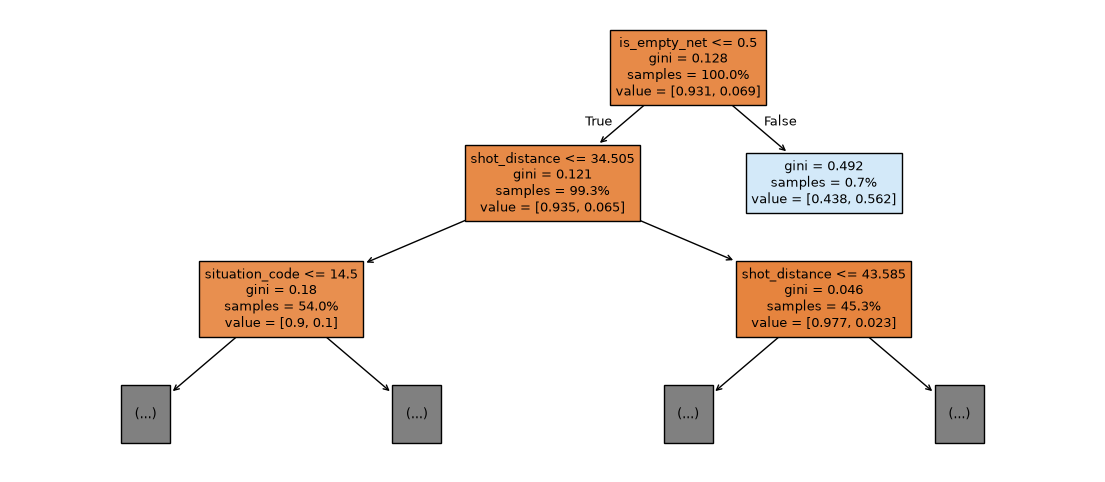

In [9]:
from sklearn.tree import plot_tree

tree = trees.fit_tree(trn_xs, trn_y)
plt.figure(figsize=(14, 6))
plot_tree(tree, max_depth=2, feature_names=list(trn_xs.columns), filled=True, proportion=True, fontsize=9);
trees.evaluate(tree, val_xs, val_y)

A random forest = many trees on bagged rows/columns, averaged (bagging cancels
individual-tree variance):

In [10]:
rf = trees.fit_forest(trn_xs, trn_y)
print('oob score:', round(rf.oob_score_, 4))
trees.evaluate(rf, val_xs, val_y)

oob score: 0.9319


{'log_loss': 0.22579854359773313,
 'auc': 0.755159441088436,
 'xg_sum': np.float64(233.18291720270614),
 'goals': 223}

AUC ≈ 0.74 on ~130 games of data — inside sight of the public-model range, and the summed
xG on validation is close to actual goals. The payoff plot — **feature importance**:

shot_distance             0.131
shot_angle                0.075
event_id                  0.056
shooter_id                0.055
game_seconds              0.054
opponent_skaters          0.048
x_coord                   0.047
y_coord                   0.040
is_empty_net              0.035
log_seconds_since_prev    0.035
goalie_id                 0.034
seconds_since_prev        0.033
day_of_season             0.033
venue                     0.031
opponent_team             0.031
dtype: float64

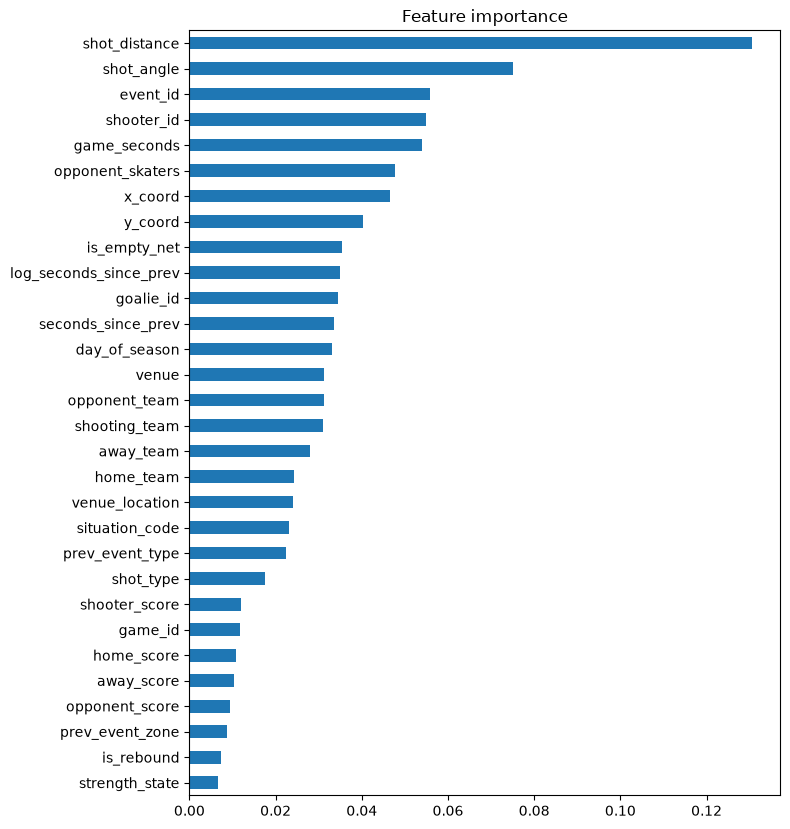

In [11]:
imp = trees.plot_importance(rf, trn_xs.columns, top=30)
imp.head(15).round(3)

Reading it with the skill's priors in mind:

- **`shot_distance` / `shot_angle` / coordinates dominate** — as every public xG model finds.
- **`is_empty_net`, strength columns** — near-automatic goals and PP context.
- **Identifier columns (`event_id`, `game_id`, `shooter_id`, `day_of_season`) show nonzero
  importance** — that's the cost of "exclude nothing": trees happily mine noise (or shooter
  identity, which is real signal but tiny-sample here). These are the first candidates to drop
  or restructure in the next iteration.

## 3. Neural net trained by gradient descent, from scratch (nb04 + nb05)

For gradient descent, categoricals become one-hot dummies (high-cardinality ids stay integer
codes) and every column is normalized to [0,1] by its **train-set** max — nb05's recipe.

In [12]:
trn_d, val_d = features.dummy_frame(trn), features.dummy_frame(val)
t_trn, y_trn, cols, maxes = features.to_tensors(trn_d)
t_val, y_val, _, _ = features.to_tensors(val_d, maxes=maxes)
t_trn.shape, t_val.shape

(torch.Size([8946, 280]), torch.Size([3104, 280]))

A model is just a coefficient tensor; a prediction is `sigmoid(sum(features × coeffs))`,
so outputs are probabilities. One manual gradient-descent step, exactly nb04's mechanics
(`loss.backward()`, step against the gradient, zero the grad):

In [13]:
coeffs = nn.init_coeffs(t_trn.shape[1])
loss = nn.calc_loss(nn.linear_preds, coeffs, t_trn, y_trn)
print('initial loss', loss.item())
loss.backward()
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 2.0)
    coeffs.grad.zero_()
print('after 1 step', nn.calc_loss(nn.linear_preds, coeffs, t_trn, y_trn).item())

initial loss 0.9611814618110657
after 1 step 0.4826086461544037


One change from nb05: the loss is **binary cross-entropy (= log loss)** rather than MAE —
the proper scoring rule for probabilities, and directly comparable with the forest above.
Now the full training loop (`nn.train` is nb05's `train_model`):

In [14]:
coeffs = nn.init_coeffs(t_trn.shape[1])
coeffs, hist = nn.train(nn.linear_preds, coeffs, t_trn, y_trn, t_val, y_val, epochs=60, lr=2.0)
nn.evaluate(nn.linear_preds, coeffs, t_val, y_val)

epoch   0  trn 0.9612  val 0.4853
epoch  10  trn 0.2687  val 0.2757


epoch  20  trn 0.2564  val 0.2672
epoch  30  trn 0.2489  val 0.2620
epoch  40  trn 0.2440  val 0.2583
epoch  50  trn 0.2403  val 0.2555
epoch  59  trn 0.2377  val 0.2535


{'log_loss': 0.2534787356853485, 'xg_sum': 248.87716674804688, 'goals': 223}

Strongest linear coefficients — the linear model's version of feature importance:

In [15]:
cw = pd.Series(coeffs.detach().numpy(), index=cols).sort_values()
pd.concat([cw.head(8), cw.tail(8)]).round(2)

game_id                       -0.88
strength_state_5v5            -0.70
venue_location_Pittsburgh     -0.54
away_team_CBJ                 -0.48
shot_distance                 -0.48
zone_code_O                   -0.47
situation_code_0641           -0.47
shot_type_slap                -0.47
is_empty_net                   0.42
home_team_TOR                  0.42
venue_Capital One Arena        0.46
venue_location_Elmont          0.46
venue_Madison Square Garden    0.48
away_team_PHI                  0.52
home_team_MIN                  0.54
strength_state_5v6             0.71
dtype: float32

**One hidden layer** (matrix multiply → ReLU → matrix multiply → sigmoid), still trained by
the same manual loop:

In [16]:
nn_c = nn.init_nn_coeffs(t_trn.shape[1], n_hidden=20)
nn_c, nn_hist = nn.train(nn.nn_preds, nn_c, t_trn, y_trn, t_val, y_val, epochs=60, lr=2.0)
nn.evaluate(nn.nn_preds, nn_c, t_val, y_val)

epoch   0  trn 1.2676  val 0.2593
epoch  10  trn 0.2430  val 0.2508
epoch  20  trn 0.2396  val 0.2486
epoch  30  trn 0.2367  val 0.2469
epoch  40  trn 0.2340  val 0.2455
epoch  50  trn 0.2315  val 0.2441
epoch  59  trn 0.2293  val 0.2428


{'log_loss': 0.2428281009197235, 'xg_sum': 224.73391723632812, 'goals': 223}

**Deep net** (two hidden layers):

In [17]:
deep_c = nn.init_deep_coeffs(t_trn.shape[1], hiddens=(10, 10))
deep_c, deep_hist = nn.train(nn.deep_preds, deep_c, t_trn, y_trn, t_val, y_val, epochs=60, lr=2.0)
nn.evaluate(nn.deep_preds, deep_c, t_val, y_val)

epoch   0  trn 12.8022  val 0.6196
epoch  10  trn 0.2534  val 0.2602
epoch  20  trn 0.2500  val 0.2584
epoch  30  trn 0.2498  val 0.2584


epoch  40  trn 0.2498  val 0.2585


epoch  50  trn 0.2498  val 0.2585


epoch  59  trn 0.2498  val 0.2585


{'log_loss': 0.25846391916275024, 'xg_sum': 212.75213623046875, 'goals': 223}

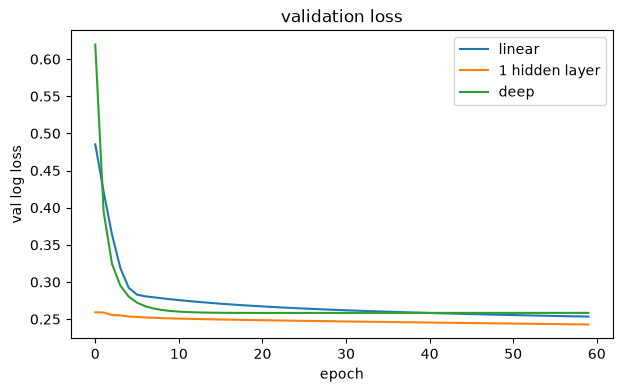

In [18]:
plt.figure(figsize=(7, 4))
for h, label in [(hist, 'linear'), (nn_hist, '1 hidden layer'), (deep_hist, 'deep')]:
    plt.plot(h, label=label)
plt.xlabel('epoch'); plt.ylabel('val log loss'); plt.legend(); plt.title('validation loss');

Calibration — does a shot we call 15% xG actually go in 15% of the time?

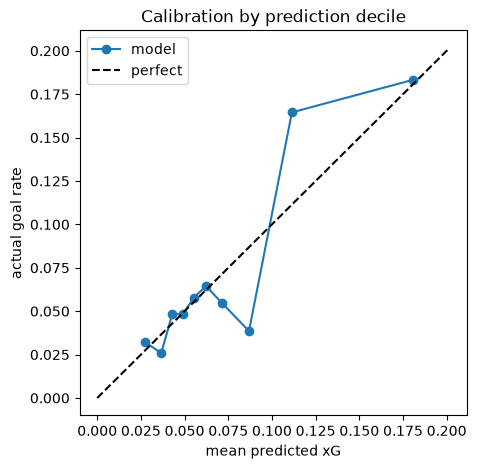

In [19]:
with torch.no_grad():
    val_preds = nn.nn_preds(nn_c, t_val)
nn.calibration_plot(val_preds, y_val)

## Wrap-up

| model | val log loss | val AUC | Σ xG vs goals |
|---|---|---|---|
| random forest | see §2 | see §2 | see §2 |
| linear (from scratch) | see above | — | see above |
| 1-hidden-layer NN | see above | — | see above |

Next iterations, in rough order of value:

1. **More data** — pull more cached games (`build_shot_dataframe` caches as it goes); public
   models train on hundreds of thousands of shots.
2. **Prune the identifier noise** the importance plot exposed (`event_id`, `game_id`, raw ids).
3. **Strength-state splits** — fit/report 5v5 separately per the interpretation rules.
4. **Flurry adjustment & rebound chains** — discount later shots in a flurry.
5. **Shooter talent** — replace raw `shooter_id` with a career goals-vs-xG prior (Bayesian, à la
   MoneyPuck) instead of a 700-level categorical.
6. **Arena-adjusted coordinates** — recorded shot locations have known rink-to-rink bias.

Remember the caveat: xG numbers are model-specific — when quoting these, they're *this* model's
xG, not MoneyPuck's or Evolving Hockey's.